In [24]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import torch.nn as nn


In [25]:
# helper functions

# def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
#                            beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

#     rows = []
#     t = pd.to_datetime(t)
#     if not stocks:
#         return torch.empty((0, 2), dtype=torch.float32)
#     for stock in stocks:
#         # Get factors for stock at time t (or default values if missing)
#         sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
#         market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
#         pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
#         implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
#         short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
#         beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
#         op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
#         roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
#         rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
#         turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

#         # Get volatility at time t (or nearest available)
#         if t in volatility.index and stock in volatility.columns:
#             vol = volatility.loc[t, stock]
#         else:
#             # Get closest date
#             available_dates = volatility.index[volatility.index <= t]
#             if len(available_dates) > 0:
#                 closest_date = available_dates[-1]
#                 vol = volatility.loc[closest_date, stock]
#             else:
#                 vol = 0.0  # Default if no data available
#         rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
#         # features is (N, 11)
#     features = np.array(rows, dtype=np.float32)
#     features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


#     # if len(features) >0:
#     #     num_cols = features.shape[1]
#     #     for i in range(num_cols):  # Normalize each feature to [0, 1]
#     #         if features[:, i].max() > features[:, i].min():
#     #             features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

#     # non_zero_count = np.count_nonzero(features)
#     # total_elements = features.size
#     # zero_fraction = 1.0 - (non_zero_count / total_elements)
    
#     # if zero_fraction > 0.9: # If more than 90% of data is zero
#     #     print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
#     #     print("Sample Row (first stock):", features[0])
#     #     # Check raw dataframe lookup for one stock to debug
#     #     test_stock = stocks[0]
#     #     print(f"Debug check for {test_stock} at {t}:")
#     #     if test_stock in pe_ratios.columns:
#     #         # Check if exact date exists
#     #         date_exists = t in pe_ratios.index
#     #         print(f"  - Date {t} in PE_ratios index? {date_exists}")
#     #         if not date_exists:
#     #             # Show nearest dates
#     #             print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
                
#     return torch.tensor(features, dtype=torch.float32)


def prepare_node_features(stocks, sectors, z_data_dict, t): # 1 quarter
    """
    Normalise each feature per stock against its own rolling history (z-score),
    preserving signal relative to that stock's recent behaviour.
    """
    rows = []
    t = pd.to_datetime(t)
    
    for stock in stocks:
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        
        # Simple lookup instead of rolling calculation
        feats = [sector_id]
        for key in z_data_dict:
            df = z_data_dict[key]
            val = df.loc[t, stock] if stock in df.columns and t in df.index else 0.0
            feats.append(float(val))
            
        rows.append(feats)

    features = np.array(rows, dtype=np.float32)
    return torch.tensor(np.nan_to_num(features), dtype=torch.float32)


def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    active = window.columns[ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active


In [26]:
# basic autoencoder for anomaly detection
class Autoencoder(nn.Module):
    def __init__(self, in_dim=11, hid_dim=32, bottleneck=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hid_dim), nn.ReLU(),
            nn.Linear(hid_dim, bottleneck), nn.ReLU()
        ) # encoder consists of 2 linear layers with ReLU activations, reducing dimensionality to bottleneck size
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hid_dim), nn.ReLU(),
            nn.Linear(hid_dim, in_dim)
        ) # decoder consists of 2 linear layers with ReLU activations, reconstructing back to original feature size

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
# load data
def load_and_fix_index(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
    df = df[~df.index.duplicated(keep='last')]
    df.dropna(how='all', inplace=True)
    #df = df.ffill().bfill()
    return df

# Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv').
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
# Example placeholder setup to make this runnable in context
# Replace these lines with your actual data loading block
# ---------------------------------------------------------
returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
returns = returns.ffill().bfill()
all_stocks = returns.columns.get_level_values(0).unique().tolist()
# ---------------------------------------------------------
train_returns = returns.loc['2012-01-01':'2019-06-30']
test_returns = returns.loc['2019-07-01':'2024-12-31']
volatility = returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)

feature_dfs_list = [
    Market_caps, PE_ratios, Implied_vol, Beta, 
    Operating_margin, Return_on_equity, RSI_momentum, 
    Short_interest, Turnover, volatility
]
K = 21
# Train/Test Split
train_dates = train_returns.index # Example subset
test_dates = test_returns.index
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)
test_prices = prices.loc['2019-07-01':'2024-12-31']
train_prices = prices.loc['2012-01-01':'2019-06-30']
train_volatility = volatility.loc['2012-01-01':'2019-06-30']


C:\Users\archi\AppData\Local\Temp\ipykernel_26076\1763093991.py:32: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')


In [28]:
print('Precomputing Z scores for all features...')

def precompute_zscores(df, window=63):
    """Calculates rolling z-scores for an entire dataframe at once."""
    rolling_mean = df.rolling(window=window, min_periods=5).mean()
    rolling_std = df.rolling(window=window, min_periods=5).std()
    # Avoid division by zero with 1e-8
    z_scores = (df - rolling_mean) / (rolling_std + 1e-8)
    # Clip outliers to keep gradients stable and fill NaNs
    return z_scores.clip(-5.0, 5.0).fillna(0.0)

# Precompute z-scores for all feature dataframes
Z_DATA = {
    'volatility':       precompute_zscores(volatility), # use your vol_window here
    'market_caps':      precompute_zscores(Market_caps),
    'pe_ratios':        precompute_zscores(PE_ratios),
    'implied_vol':      precompute_zscores(Implied_vol),
    'short_interest':   precompute_zscores(Short_interest),
    'beta':             precompute_zscores(Beta),
    'op_margin':        precompute_zscores(Operating_margin),
    'roe':              precompute_zscores(Return_on_equity),
    'rsi':              precompute_zscores(RSI_momentum),
    'turnover':         precompute_zscores(Turnover)
}

Precomputing Z scores for all features...


In [29]:
# # Collect all training features first
# from sklearn.preprocessing import StandardScaler

# all_features = []
# print(f'Loading Dataset')
# for t in train_dates:
#     stocks = get_active_stocks(train_returns, t, lookback_days=K, feature_dfs=feature_dfs_list)
#     X = prepare_node_features(stocks, sectors, Z_DATA, t) # with the fix
#     all_features.append(X)

# seed_vals = [0, 2, 4, 6] # seeds for reproducibility
# hid_dem = [16, 32, 64, 128] # hidden dimension for autoencoder
# bottleneck = [4, 8, 16, 32]
# lrs = [1e-4, 1e-3, 5e-3,1e-2 ]

# all_features = np.vstack(all_features)
# all_features_tens = torch.tensor(all_features, dtype=torch.float32)

# # Then train properly
# dataset = torch.utils.data.TensorDataset(all_features_tens)
# loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)

# models = []
# for seed in seed_vals:
#     print(f"\n[Training Autoencoder with Seed {seed}]")
#     torch.manual_seed(seed)
#     np.random.seed(seed)
#     model = Autoencoder()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#     for epoch in range(50):
#         for (batch,) in loader:
#             x_hat = model(batch)
#             loss = ((batch - x_hat) ** 2).mean()
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
#     models.append(model)

In [30]:
from sklearn.metrics import roc_auc_score

def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:
        #print(f'working on date {t}')

        stocks, signals = test_results[t]
        #print(f'stocks: {stocks[:5]}... signals: {signals[:5]}...')

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]
        #print(f'available stocks for evaluation: {available[:5]}...')

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]
        #print(f'mask: {mask}')

        signals = signals[mask]
        #print(f'signals: {signals}')

        p_t = prices.loc[t, available]
        #print(f'prices at time {t} for available stocks: {p_t[:5]}...') PROBLEM IN THIS LINE

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int) # 1 if crash, 0 if not
        #signals = np.where(signals == -1, 1, 0) # Convert Isolation Forest output to 1 for anomaly (crash signal), 0 for normal

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline

In [31]:
from itertools import product

# ── Hyperparameter grid ────────────────────────────────────────────────────────
seed_vals   = [0, 2, 4, 6]
hid_dem     = [16, 32, 64, 128]
bottleneck  = [4, 8, 16, 32]
lrs         = [1e-4, 1e-3, 5e-3, 1e-2]

# ── Temporal splits ────────────────────────────────────────────────────────────
# Grid search trains on 2012-2016, validates on 2017-2019-06. Test untouched.
gs_train_returns = returns.loc["2012-01-01":"2016-12-31"]
gs_val_returns   = returns.loc["2017-01-01":"2019-06-30"]
gs_train_dates   = gs_train_returns.index
gs_val_dates     = gs_val_returns.index
gs_val_prices    = prices.loc["2017-01-01":"2019-06-30"]

# ── Build 2012-2016 train loader ───────────────────────────────────────────────
print("Extracting GS training features (2012-2016)...")
gs_train_feats = []
for t in gs_train_dates:
    stocks = get_active_stocks(gs_train_returns, t, lookback_days=K, feature_dfs=feature_dfs_list)
    gs_train_feats.append(prepare_node_features(stocks, sectors, Z_DATA, t))

gs_train_tens = torch.tensor(np.vstack(gs_train_feats), dtype=torch.float32)
gs_loader     = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(gs_train_tens), batch_size=512, shuffle=True
)
IN_DIM = gs_train_tens.shape[1]

# ── Build full 2012-2019 train loader (for final retrain) ─────────────────────
print("Extracting full training features (2012-2019)...")
full_train_returns = returns.loc["2012-01-01":"2019-06-30"]
full_train_feats = []
for t in full_train_returns.index:
    stocks = get_active_stocks(full_train_returns, t, lookback_days=K, feature_dfs=feature_dfs_list)
    full_train_feats.append(prepare_node_features(stocks, sectors, Z_DATA, t))

full_train_tens = torch.tensor(np.vstack(full_train_feats), dtype=torch.float32)
full_loader     = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(full_train_tens), batch_size=512, shuffle=True
)

# ── Helper: score an ensemble over a set of dates ─────────────────────────────
def score_on_dates(trained_models, dates, returns_df):
    results = {}
    for t in dates:
        stocks = get_active_stocks(returns_df, t, lookback_days=K, feature_dfs=feature_dfs_list)
        X = prepare_node_features(stocks, sectors, Z_DATA, t)
        all_scores = []
        for m in trained_models:
            with torch.no_grad():
                scores = ((X - m(X)) ** 2).sum(dim=1).numpy()
            all_scores.append(scores)
        results[t] = (stocks, np.mean(all_scores, axis=0))
    return results

# ── Grid search (validated on 2017-2019, test never touched) ──────────────────
EVAL_FW = [10, 22]
EVAL_CT = [-0.10, -0.20, -0.30]

combos = [(h, b, l, fw, ct) for h, b, l, fw, ct in product(hid_dem, bottleneck, lrs, EVAL_FW, EVAL_CT) if b < h]
print(f"Running {len(combos)} combinations on validation set (2017-2019)...")

gs_results = []
for hid_dim_i, bottleneck_i, lr_i, fw_i, ct_i in combos:
    trained_models = []
    for seed in seed_vals:
        torch.manual_seed(seed)
        np.random.seed(seed)
        m = Autoencoder(in_dim=IN_DIM, hid_dim=hid_dim_i, bottleneck=bottleneck_i)
        opt = torch.optim.Adam(m.parameters(), lr=lr_i)
        for epoch in range(50):
            for (batch,) in gs_loader:
                x_hat = m(batch)
                loss = ((batch - x_hat) ** 2).mean()
                opt.zero_grad(); loss.backward(); opt.step()
        trained_models.append(m)

    val_results = score_on_dates(trained_models, gs_val_dates, gs_val_returns)
    result = evaluate_once(val_results, gs_val_prices, fw_i, ct_i)
    auc = result[0] if result is not None else float("nan")

    gs_results.append({"hid_dim": hid_dim_i, "bottleneck": bottleneck_i, "lr": lr_i, "val_AUC": auc})
    print(f"hid={hid_dim_i:3d}  bot={bottleneck_i:2d}  lr={lr_i:.0e}  val_AUC={auc:.4f}")

df_gs = pd.DataFrame(gs_results).sort_values("val_AUC", ascending=False)
print("--- Top 10 Configurations (Validation) ---")
print(df_gs.head(10).to_string(index=False))

# ── Retrain best config on full 2012-2019 data ────────────────────────────────
best     = df_gs.iloc[0]
best_hid = int(best["hid_dim"])
best_bot = int(best["bottleneck"])
best_lr  = best["lr"]
print(f"Best config: hid_dim={best_hid}, bottleneck={best_bot}, lr={best_lr:.0e}")
print("Retraining on full 2012-2019 data...")

final_models = []
for seed in seed_vals:
    torch.manual_seed(seed)
    np.random.seed(seed)
    m = Autoencoder(in_dim=IN_DIM, hid_dim=best_hid, bottleneck=best_bot)
    opt = torch.optim.Adam(m.parameters(), lr=best_lr)
    for epoch in range(50):
        for (batch,) in full_loader:
            x_hat = m(batch)
            loss = ((batch - x_hat) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
    final_models.append(m)

print("Done. Use final_models in the test cell below.")


Extracting GS training features (2012-2016)...
Extracting full training features (2012-2019)...
Running 312 combinations on validation set (2017-2019)...
hid= 16  bot= 4  lr=1e-04  val_AUC=0.5678
hid= 16  bot= 4  lr=1e-04  val_AUC=0.6039
hid= 16  bot= 4  lr=1e-04  val_AUC=0.5238
hid= 16  bot= 4  lr=1e-04  val_AUC=0.5741
hid= 16  bot= 4  lr=1e-04  val_AUC=0.5809
hid= 16  bot= 4  lr=1e-04  val_AUC=0.5152
hid= 16  bot= 4  lr=1e-03  val_AUC=0.5790
hid= 16  bot= 4  lr=1e-03  val_AUC=0.6171
hid= 16  bot= 4  lr=1e-03  val_AUC=0.5450
hid= 16  bot= 4  lr=1e-03  val_AUC=0.5783
hid= 16  bot= 4  lr=1e-03  val_AUC=0.5933
hid= 16  bot= 4  lr=1e-03  val_AUC=0.5483
hid= 16  bot= 4  lr=5e-03  val_AUC=0.5706
hid= 16  bot= 4  lr=5e-03  val_AUC=0.6021
hid= 16  bot= 4  lr=5e-03  val_AUC=0.5085
hid= 16  bot= 4  lr=5e-03  val_AUC=0.5709
hid= 16  bot= 4  lr=5e-03  val_AUC=0.5822
hid= 16  bot= 4  lr=5e-03  val_AUC=0.5274
hid= 16  bot= 4  lr=1e-02  val_AUC=0.5728
hid= 16  bot= 4  lr=1e-02  val_AUC=0.6222
hid= 1

KeyboardInterrupt: 

In [ ]:
# testing
test_results = {} # t: (stocks, signals)

for t in test_dates:
    #print(f'evaluating on date {t}')
    stocks = get_active_stocks(test_returns, t, lookback_days=K, feature_dfs=feature_dfs_list)
    test_features = prepare_node_features(stocks, sectors, Z_DATA, t)
    #test_features_np = scaler.transform(test_features.numpy())

    X_test = torch.tensor(test_features, dtype=torch.float32)
    all_scores = []
    for m in final_models:  # tuned ensemble from grid search
        with torch.no_grad():
            x_hat = m(X_test)
            scores = ((X_test - x_hat) ** 2).sum(dim=1).numpy()
        all_scores.append(scores)

    avg_scores = np.mean(all_scores, axis=0)
    test_results[t] = (stocks, avg_scores)

pd.to_pickle(test_results, 'basic_AE_test_results.pkl')

C:\Users\archi\AppData\Local\Temp\ipykernel_11432\3045434538.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(test_features, dtype=torch.float32)
C:\Users\archi\AppData\Local\Temp\ipykernel_11432\3045434538.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(test_features, dtype=torch.float32)
C:\Users\archi\AppData\Local\Temp\ipykernel_11432\3045434538.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(test_features, dtype=torch.float32)
C:\Users\archi\AppData\Local

In [ ]:
import pandas as pd
import numpy as np
import torch

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)


In [ ]:
forward_windows = [5,10,22,44,66]

crash_thresholds = [-0.05,-0.10,-0.15,-0.20,-0.30]

#test_results = pd.read_pickle("outputs/test_results_test_fix3Mar.pkl")

#test_prices = pd.read_pickle("outputs/test_prices_test_fix3Mar.pkl") 

df_results = grid_search(

    test_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW=  5 CT= -0.05 AUC=0.543 Lift=1.20
FW=  5 CT= -0.10 AUC=0.583 Lift=1.29
FW=  5 CT= -0.15 AUC=0.617 Lift=1.30
FW=  5 CT= -0.20 AUC=0.617 Lift=1.20
FW=  5 CT= -0.30 AUC=0.616 Lift=1.27
FW= 10 CT= -0.05 AUC=0.524 Lift=1.10
FW= 10 CT= -0.10 AUC=0.555 Lift=1.23
FW= 10 CT= -0.15 AUC=0.586 Lift=1.19
FW= 10 CT= -0.20 AUC=0.594 Lift=0.99
FW= 10 CT= -0.30 AUC=0.599 Lift=0.87
FW= 22 CT= -0.05 AUC=0.517 Lift=1.07
FW= 22 CT= -0.10 AUC=0.536 Lift=1.20
FW= 22 CT= -0.15 AUC=0.565 Lift=1.34
FW= 22 CT= -0.20 AUC=0.590 Lift=1.47
FW= 22 CT= -0.30 AUC=0.612 Lift=1.47
FW= 44 CT= -0.05 AUC=0.516 Lift=1.06
FW= 44 CT= -0.10 AUC=0.527 Lift=1.16
FW= 44 CT= -0.15 AUC=0.539 Lift=1.28
FW= 44 CT= -0.20 AUC=0.558 Lift=1.44
FW= 44 CT= -0.30 AUC=0.573 Lift=1.48
FW= 66 CT= -0.05 AUC=0.524 Lift=1.10
FW= 66 CT= -0.10 AUC=0.533 Lift=1.20
FW= 66 CT= -0.15 AUC=0.543 Lift=1.32
FW= 66 CT= -0.20 AUC=0.565 Lift=1.54
FW= 66 CT= -0.30 AUC=0.593 Lift=1.83



[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 10 days, Crash Threshold: -5.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.5491  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0111   (Correlation with actual crashes)
3. Precision (Top 10%):17.77% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:13.05% (Random probability of a crash)
5. Model Lift:         1.36x    (Model is 1.4 times better than random guessing)
------------------------------------------------------------


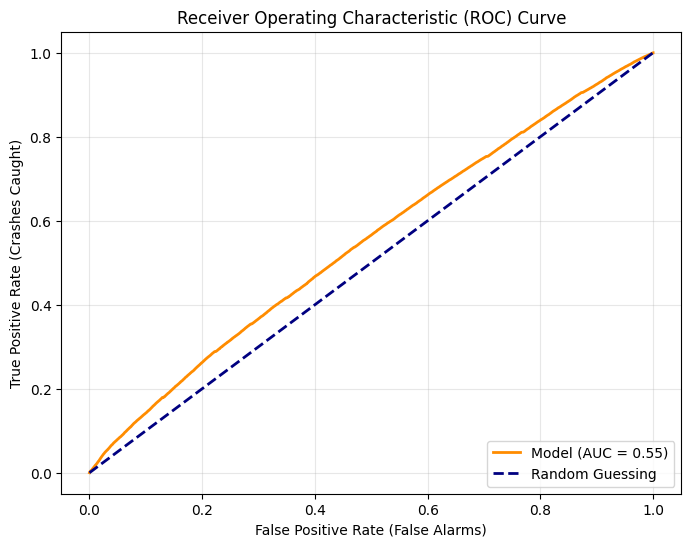


Sample Successful 'Bubble Bursts' Predicted:
      Date          Stock     Signal  Return_Next_Month
2020-01-22  AMD UW Equity   0.896766          -0.066304
2020-01-27 PAYC UN Equity  10.635121          -0.069817
2020-01-27    F UN Equity   3.161452          -0.071991
2020-01-28    F UN Equity   3.302746          -0.095875
2020-01-29    F UN Equity   3.014928          -0.090293
2020-01-30    F UN Equity   2.988613          -0.088235
2020-01-31    F UN Equity   3.069307          -0.086168
2020-02-03    F UN Equity   3.084882          -0.081292
2020-02-04 TSLA UW Equity 120.078026          -0.098111
2020-02-04    F UN Equity   3.317940          -0.117647


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score
import matplotlib.pyplot as plt

def evaluate_predictive_power(test_results, prices, forward_window=22, crash_threshold=-0.10):
    """
    Calculates accuracy by checking if high signals actually lead to price drops.
    
    Args:
        forward_window: Days to look ahead (e.g., 22 days = 1 month)
        crash_threshold: Return threshold to define a 'Real Crash' (e.g., -0.10 means -10% drop)
    """
    print("\n[Accuracy Evaluation] Calculating Predictive Power...")
    
    y_true = []   # 1 if stock actually crashed, 0 otherwise
    y_scores = [] # Your anomaly signal
    
    # List to track specific successful predictions for debugging
    successful_calls = []
    
    sorted_dates = sorted(list(test_results.keys()))
    
    # We stop early so we have enough data for the forward window
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window*1.5)]
    
    for t in valid_dates:
        stocks, signals = test_results[t]
        
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()
        
        # Calculate Forward Returns for these stocks
        # Get price at t
        p_t = prices.loc[t, stocks]
        
        # Get price at t + window
        # Find nearest valid date in future
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices): continue
        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, stocks]
        
        # Return calculation
        fwd_returns = (p_future - p_t) / p_t
        
        # Define Ground Truth: Did it crash?
        # If return < -10%, it is a "True Anomaly" (Class 1)
        is_crash = (fwd_returns < crash_threshold).astype(int)
        #signals = np.where(signals == -1, 1, 0) # Convert Isolation Forest output to 1 for anomaly (crash signal), 0 for normal
        
        y_true.extend(is_crash.values)
        y_scores.extend(signals)
        
        # Track Top Predictions
        # Combine into dataframe
        df_eval = pd.DataFrame({'Stock': stocks, 'Signal': signals, 'Return': fwd_returns, 'Crash': is_crash})
        top_picks = df_eval.sort_values('Signal', ascending=False).head(5)
        
        for _, row in top_picks.iterrows():
            if row['Crash'] == 1:
                successful_calls.append({
                    'Date': t.strftime('%Y-%m-%d'),
                    'Stock': row['Stock'],
                    'Signal': row['Signal'],
                    'Return_Next_Month': row['Return']
                })

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # --- METRIC 1: AUC-ROC ---
    # Can the model distinguish between a crash and normal price action?
    auc = roc_auc_score(y_true, y_scores)
    
    # --- METRIC 2: Information Coefficient (IC) ---
    # Correlation between Signal and Crash Probability
    # Ideally Positive (Higher Signal = Higher Probability of Crash)
    ic = np.corrcoef(y_scores, y_true)[0, 1]
    
    # --- METRIC 3: Precision @ Top 10% ---
    # If we take the top 10% highest signals, what % were actually crashes?
    threshold_top_10 = np.percentile(y_scores, 90)
    high_signal_indices = y_scores > threshold_top_10
    
    precision_top_10 = np.mean(y_true[high_signal_indices]) # % of high signals that were crashes
    baseline_crash_rate = np.mean(y_true) # % of ALL stocks that crashed
    
    # Lift: How much better is the model than random chance?
    lift = precision_top_10 / baseline_crash_rate if baseline_crash_rate > 0 else 0
    
    print("-" * 60)
    print(f"PREDICTIVE ACCURACY (Forward Window: {forward_window} days, Crash Threshold: {crash_threshold*100}%)")
    print("-" * 60)
    print(f"1. AUC-ROC Score:      {auc:.4f}  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)")
    print(f"2. Info Coefficient:   {ic:.4f}   (Correlation with actual crashes)")
    print(f"3. Precision (Top 10%):{precision_top_10:.2%} (Of highest signals, this % actually crashed)")
    print(f"4. Baseline Crash Rate:{baseline_crash_rate:.2%} (Random probability of a crash)")
    print(f"5. Model Lift:         {lift:.2f}x    (Model is {lift:.1f} times better than random guessing)")
    print("-" * 60)
    
    # --- Visualization: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.2f})", color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Crashes Caught)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\nSample Successful 'Bubble Bursts' Predicted:")
    print(pd.DataFrame(successful_calls).head(10).to_string(index=False))

# ==============================================================================
# EXECUTION
# ==============================================================================

    # Evaluate 1-Month Forward Accuracy looking for -15% Drops
evaluate_predictive_power(test_results, test_prices, forward_window=10, crash_threshold=-0.05)
